In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
import helpers.test_circ_plot as circ_plot


ss = hf.settings_dict()

In [2]:
# important variables
tmin = 1
tmax = 1.5

loading dataset for subject:  0005_3SJ
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0005_3SJ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1440 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Showing: t = 1.349 s, (-26.4, -49.1, -6.9) mm, [5, 6, 7] vox, 2195 vertex


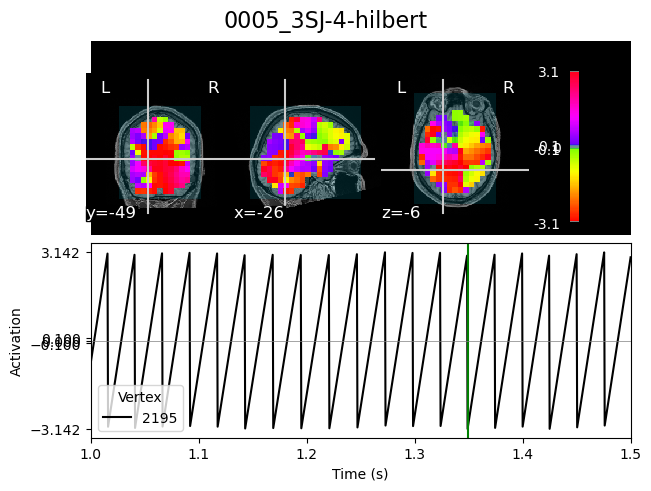

Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0005_3SJ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1440 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/test_circ_plot.py:43: UserWarning: kwargs['alpha']=0.6 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  plot_stat_map(img,


<Figure size 600x800 with 0 Axes>

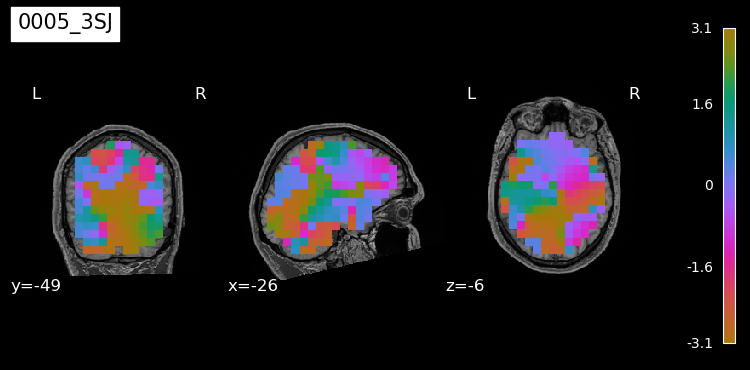

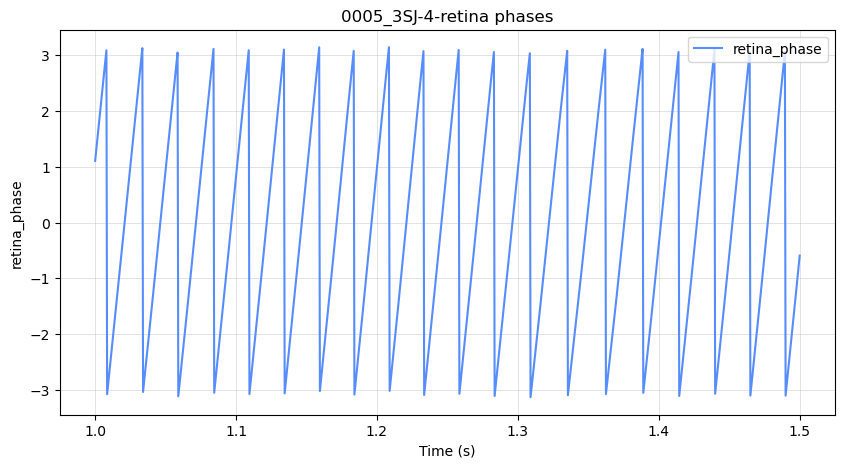

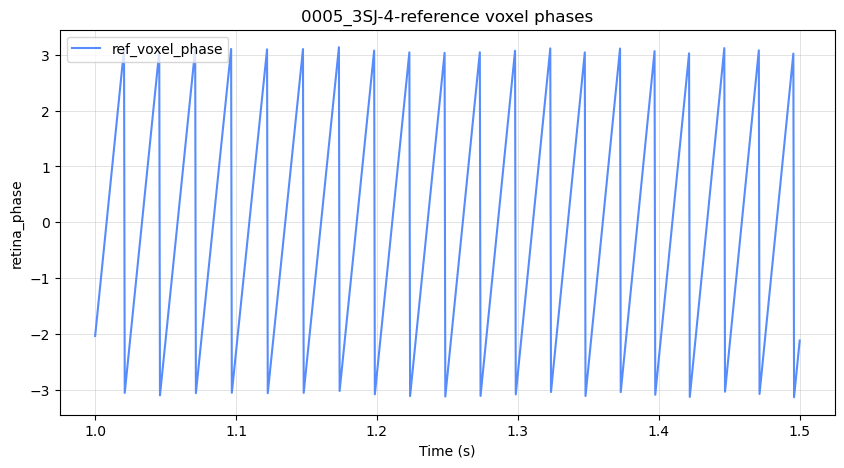

loading dataset for subject:  0002_TCZ
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0002_TCZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1868 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Showing: t = 1.167 s, (-60.9, 40.0, 29.6) mm, [2, 14, 9] vox, 3656 vertex


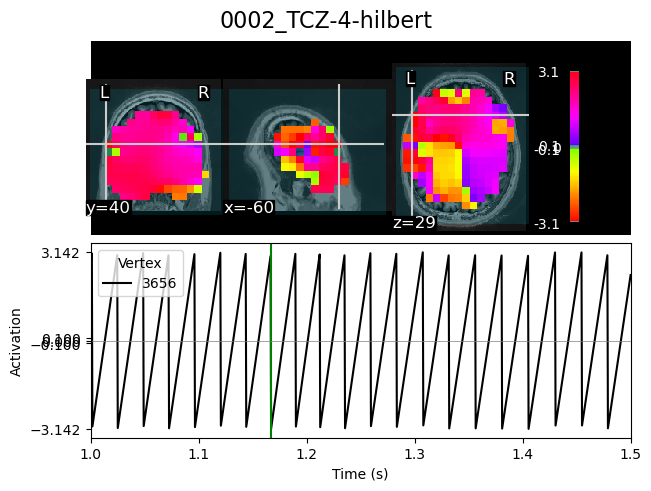

Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0002_TCZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1868 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/test_circ_plot.py:43: UserWarning: kwargs['alpha']=0.6 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  plot_stat_map(img,


<Figure size 600x800 with 0 Axes>

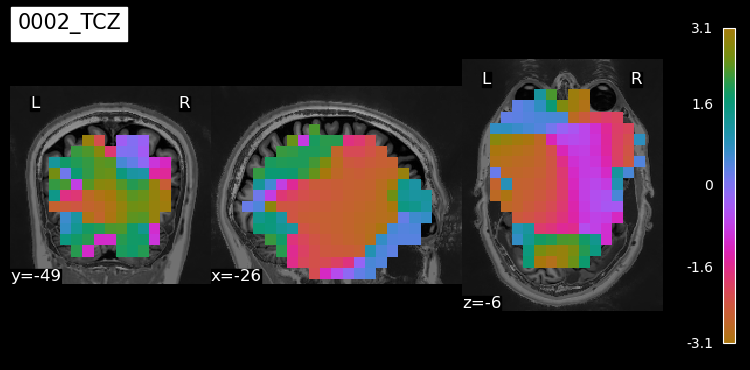

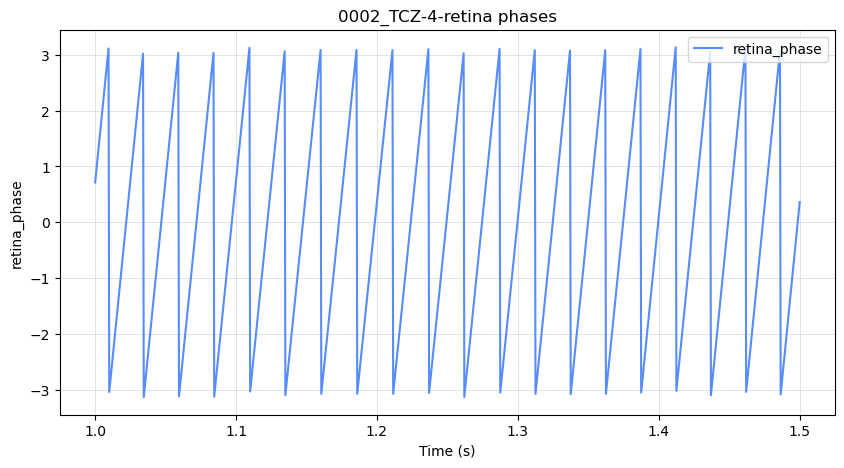

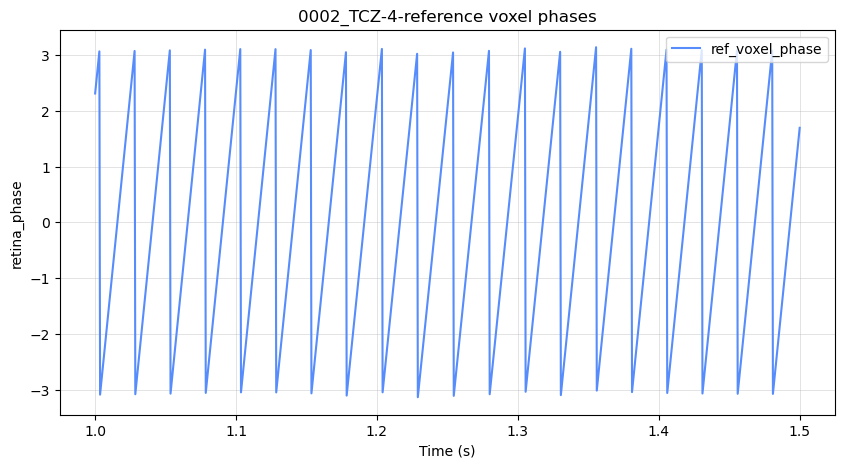

In [3]:
#TODO: make a better plotting function
#TODO: plot the phase differences too
for subject_index in ss['subject_idx_list']:
    # loop over each event type
    for event_id in ss['event_id_list']:
        event_name = str(event_id)
        subjects_dir = ss['fs_subjects_dir']
        subject = ss['subject_id_list'][subject_index]
        print("loading dataset for subject: ", subject)

        hilbert_stc_file = Path(ss['hilbert_dir']) / subject / event_name / f"{subject}-event-{event_name}-hilbert-vol.stc"

        stc = mne.read_source_estimate(hilbert_stc_file)

        fwd_fname = op.join(ss['fwd_dir'], subject + '-fwd.fif')
        fwd = mne.read_forward_solution(fwd_fname)
        src = fwd['src']

        if src[0]['subject_his_id'].startswith("fs"):
            src[0]['subject_his_id'] = subject

        brain = mne.viz.plot_volume_source_estimates(
            stc.copy().crop(tmin=tmin, tmax=tmax),
            subject=subject,
            subjects_dir=subjects_dir,
            src=src,
            clim=dict(kind="value", pos_lims=[0, 0.1, np.pi]),
            colormap="hsv",
            show=False,
            transparent=True,)
        # Add a title to the figure
        brain.suptitle(f"{subject}-{event_name}-hilbert", fontsize=16)

        # Display the plot
        plt.show()

        # EXPERIMENTAL PLOT FUNCTION

        circ_plot.plot_circ_stat_map(stc.copy(),
                                     subject=subject,
                                     subjects_dir=subjects_dir,
                                     time=1.349,
                                     title=f"{subject}-{event_name}-hilbert-circ",)

        # Plot the retina signal over time

        retina_file = Path(ss['hilbert_dir']) / subject / event_name / f"{subject}-event-{event_name}-reference.csv"

        # Read the CSV file
        df = pd.read_csv(retina_file)
        df_cropped = df[(df["time_s"] >= tmin) & (df["time_s"] <= tmax)]
        df = df_cropped


        # Plot retina phases over time
        plt.figure(figsize=(10, 5))
        plt.plot(df["time_s"], df["retina_phase"], label="retina_phase")

        # Labels and title
        plt.xlabel("Time (s)")
        plt.ylabel("retina_phase")
        plt.title(f"{subject}-{event_name}-retina phases")
        plt.grid(True)
        plt.legend()

        # Show the plot
        plt.show()


        # Plot reference voxel phases over time
        plt.figure(figsize=(10, 5))
        plt.plot(df["time_s"], df[df.axes[1][2]], label="ref_voxel_phase")

        # Labels and title
        plt.xlabel("Time (s)")
        plt.ylabel("retina_phase")
        plt.title(f"{subject}-{event_name}-reference voxel phases")
        plt.grid(True)
        plt.legend()

        # Show the plot
        plt.show()

        del stc


